# 🎯 Spike Pipeline v4 — Fixed & Clean

### Three issues fixed vs v3:
| Issue | Problem | Fix |
|-------|---------|-----|
| **A** | Spike threshold computed on full train (includes val → future leakage) | Threshold computed ONLY from train_bv, then applied consistently everywhere |
| **B** | Ridge stacking evaluated on same data used to fit it | Ridge fit on 1st half of val, evaluated ONLY on 2nd half |
| **C** | Two different thresholds used for spike_mask_val vs classifier labels | Single threshold from train_bv used for everything |

### Kept from v3:
- Spike probability as OOF feature for all regressors
- Log transform + Two-stage + Mega ensemble
- Validation CSV export

In [1]:
# ── CELL 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.linear_model import Ridge
import lightgbm as lgb
import catboost as cb

SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


In [2]:
# ── CELL 2: Config — only change things here
TRAIN_PATH = 'train_featured_1.csv'
TEST_PATH  = 'test_featured_1.csv'

ID_COL     = 'id'
TIME_COL   = 'delivery_start'
MARKET_COL = 'market'
TARGET_COL = 'target'

VAL_START = '2024-09-01'
VAL_END   = '2024-12-01'

# Spike definition: top X% by absolute value
SPIKE_PERCENTILE = 90
SPIKE_WEIGHT     = 5.0   # sample weight multiplier for spike rows
N_FOLDS          = 5     # folds for OOF spike_prob

In [3]:
# ── CELL 3: Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

train[TIME_COL] = pd.to_datetime(train[TIME_COL])
test[TIME_COL]  = pd.to_datetime(test[TIME_COL])

train[MARKET_COL] = train[MARKET_COL].astype('category')
test[MARKET_COL]  = pd.Categorical(
    test[MARKET_COL], categories=train[MARKET_COL].cat.categories
)

# Feature list — everything except identifiers and target
DROP_COLS    = {ID_COL, TARGET_COL, TIME_COL, 'delivery_end',
                'is_spike', 'sample_weight', 'spike_prob'}
ALL_FEATURES = [c for c in train.columns if c not in DROP_COLS]

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Features: {len(ALL_FEATURES)}')
print(f'Train period: {train[TIME_COL].min().date()} → {train[TIME_COL].max().date()}')
print(f'Test period : {test[TIME_COL].min().date()} → {test[TIME_COL].max().date()}')

Train: (132608, 144) | Test: (13098, 143)
Features: 141
Train period: 2023-01-01 → 2025-08-31
Test period : 2025-09-01 → 2025-11-30


In [4]:
# ── CELL 4: Train/Val split + spike threshold (FIX A + FIX C)
#
# FIX A: We split FIRST, then compute the spike threshold ONLY from train_bv.
# Previously the threshold was computed on the full train (which includes val),
# meaning the model implicitly "saw" future data when deciding what counts as a spike.
#
# FIX C: We use this single threshold consistently everywhere:
#   - is_spike labels for train_bv
#   - is_spike labels for val_chunk  (for reporting mask)
#   - is_spike labels for classifier val evaluation
#   - is_spike labels for full train retrain
# No more spike_thresh_val computed separately from val.

val_start = pd.Timestamp(VAL_START)
val_end   = pd.Timestamp(VAL_END)

train_bv  = train[train[TIME_COL] < val_start].copy()
val_chunk = train[
    (train[TIME_COL] >= val_start) & (train[TIME_COL] < val_end)
].copy()

# ── Single threshold computed ONLY from train_bv
spike_thresh = np.percentile(np.abs(train_bv[TARGET_COL]), SPIKE_PERCENTILE)

# Apply consistently to train_bv, val_chunk, and full train
for df in [train_bv, val_chunk, train]:
    df['is_spike']      = (np.abs(df[TARGET_COL]) >= spike_thresh).astype(int)
    df['sample_weight'] = 1.0 + (SPIKE_WEIGHT - 1.0) * df['is_spike']

# Spike mask for validation evaluation — same threshold
spike_mask_val = val_chunk['is_spike'].values.astype(bool)

print(f'Train before val : {train_bv.shape}')
print(f'Val chunk        : {val_chunk.shape}')
print(f'Spike threshold  : |target| >= {spike_thresh:.4f}  (from train_bv only)')
print(f'Spike rows train : {train_bv["is_spike"].sum()} ({train_bv["is_spike"].mean()*100:.1f}%)')
print(f'Spike rows val   : {val_chunk["is_spike"].sum()} ({val_chunk["is_spike"].mean()*100:.1f}%)')

Train before val : (80054, 146)
Val chunk        : (13104, 146)
Spike threshold  : |target| >= 53.7841  (from train_bv only)
Spike rows train : 8006 (10.0%)
Spike rows val   : 977 (7.5%)


In [5]:
# ── CELL 5: Helper functions

def log_transform(y):
    """Signed log1p: preserves sign, compresses extreme values.
    Handles negatives correctly: sign(y) * log1p(|y|)"""
    return np.sign(y) * np.log1p(np.abs(y))

def inv_log_transform(y):
    """Inverse of log_transform: sign(y) * expm1(|y|)"""
    return np.sign(y) * np.expm1(np.abs(y))

# Results dictionary — stores RMSE for all models for final comparison
results = {}

def evaluate(y_true, y_pred, label, store=True):
    """Compute RMSE overall, on spike rows, and on normal rows.
    spike_mask_val uses the single train_bv threshold (Fix C)."""
    r_all   = np.sqrt(mean_squared_error(y_true, y_pred))
    r_spike = np.sqrt(mean_squared_error(y_true[spike_mask_val],  y_pred[spike_mask_val]))
    r_norm  = np.sqrt(mean_squared_error(y_true[~spike_mask_val], y_pred[~spike_mask_val]))
    if store:
        results[label] = {'all': r_all, 'spike': r_spike, 'normal': r_norm}
    print(f'{label:<40} All={r_all:.4f}  Spike={r_spike:.4f}  Normal={r_norm:.4f}')
    return r_all

# ── Model hyperparameters
LGB_BASE = dict(
    n_estimators=5000, learning_rate=0.03, num_leaves=127,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED,
    force_row_wise=True, n_jobs=-1
)
CB_BASE = dict(
    iterations=5000, learning_rate=0.03, depth=8,
    subsample=0.8, colsample_bylevel=0.8, l2_leaf_reg=3.0,
    random_seed=SEED, loss_function='RMSE', eval_metric='RMSE',
    early_stopping_rounds=50, verbose=0, task_type='CPU'
)

def fit_lgb(X_tr, y_tr, X_vl, y_vl, weights=None, extra=None):
    m = lgb.LGBMRegressor(**{**LGB_BASE, **(extra or {})})
    m.fit(X_tr, y_tr, sample_weight=weights,
          categorical_feature=[MARKET_COL],
          eval_set=[(X_vl, y_vl)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(500)])
    return m

def fit_cb(X_tr, y_tr, X_vl, y_vl, weights=None, extra=None):
    Xtr = X_tr.copy(); Xvl = X_vl.copy()
    Xtr[MARKET_COL] = Xtr[MARKET_COL].astype(str)
    Xvl[MARKET_COL] = Xvl[MARKET_COL].astype(str)
    params = {**CB_BASE, **(extra or {})}
    m = cb.CatBoostRegressor(**params)
    m.fit(Xtr, y_tr, sample_weight=weights,
          cat_features=[MARKET_COL], eval_set=(Xvl, y_vl))
    return m

def pred_cb(m, X):
    Xc = X.copy(); Xc[MARKET_COL] = Xc[MARKET_COL].astype(str)
    return m.predict(Xc)

print('Helper functions ready.')

Helper functions ready.


=== SPIKE CLASSIFIER — 5-fold OOF ===
[LightGBM] [Info] Number of positive: 6804, number of negative: 57240
[LightGBM] [Info] Total Bins 28894
[LightGBM] [Info] Number of data points in the train set: 64044, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
  Fold 1/5 — AUC: 0.9023
[LightGBM] [Info] Number of positive: 5597, number of negative: 58447
[LightGBM] [Info] Total Bins 28916
[LightGBM] [Info] Number of data points in the train set: 64044, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
  Fold 2/5 — AUC: 0.8691
[LightGBM] [Info] Number of positive: 6303, number of negative: 57741
[LightGBM] [Info] Total Bins 28849
[LightGBM] [Info] Number of data points in the train set: 64044, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0

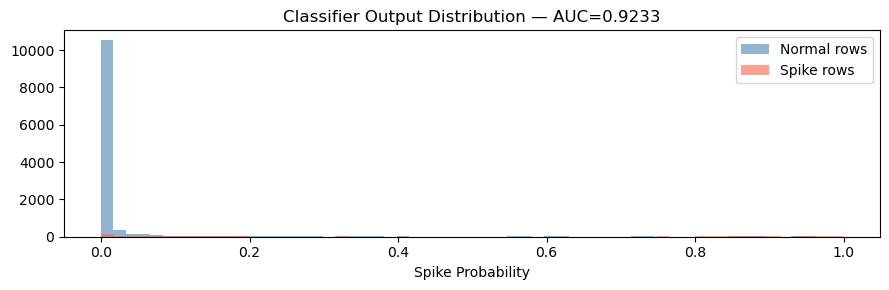

In [6]:
# ── CELL 6: Spike Classifier — OOF spike_prob as feature
#
# Why OOF (Out-of-Fold)?
# If we train the classifier on all of train_bv and then use its output
# as a feature for the regressor on the same data, the regressor sees
# "perfect" spike_prob for rows it has already been trained on → leakage.
# With 5-fold OOF: each row gets a spike_prob from a classifier that
# has NEVER seen that row → clean, leakage-free feature.
#
# FIX C applied: y_val_cls uses the single spike_thresh from train_bv.

print('=== SPIKE CLASSIFIER — 5-fold OOF ===')

y_tr_cls  = train_bv['is_spike'].values
# FIX C: same threshold for classifier val labels
y_val_cls = val_chunk['is_spike'].values

N_TR      = len(train_bv)
fold_size = N_TR // N_FOLDS
oof_spike_prob = np.zeros(N_TR)

X_tr_base = train_bv[ALL_FEATURES]

for fold in range(N_FOLDS):
    v_start = fold * fold_size
    v_end   = (fold + 1) * fold_size if fold < N_FOLDS - 1 else N_TR
    v_idx   = np.arange(v_start, v_end)
    t_idx   = np.concatenate([np.arange(0, v_start), np.arange(v_end, N_TR)])

    clf_fold = lgb.LGBMClassifier(
        n_estimators=1500, learning_rate=0.03, num_leaves=63,
        class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, force_row_wise=True, n_jobs=-1
    )
    clf_fold.fit(
        X_tr_base.iloc[t_idx], y_tr_cls[t_idx],
        categorical_feature=[MARKET_COL]
    )
    oof_spike_prob[v_idx] = clf_fold.predict_proba(
        X_tr_base.iloc[v_idx])[:, 1]
    fold_auc = roc_auc_score(y_tr_cls[v_idx], oof_spike_prob[v_idx])
    print(f'  Fold {fold+1}/{N_FOLDS} — AUC: {fold_auc:.4f}')

# Full classifier trained on all train_bv → used for val and test
clf_full = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.03, num_leaves=63,
    class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, force_row_wise=True, n_jobs=-1
)
clf_full.fit(X_tr_base, y_tr_cls, categorical_feature=[MARKET_COL])

spike_prob_val  = clf_full.predict_proba(val_chunk[ALL_FEATURES])[:, 1]
spike_prob_test = clf_full.predict_proba(test[ALL_FEATURES])[:, 1]

val_auc = roc_auc_score(y_val_cls, spike_prob_val)
print(f'\nClassifier AUC on val : {val_auc:.4f}  (>0.85 good, >0.90 excellent)')
print(f'OOF spike_prob — mean : {oof_spike_prob.mean():.3f}  max: {oof_spike_prob.max():.3f}')
print(f'Val spike_prob — mean : {spike_prob_val.mean():.3f}  max: {spike_prob_val.max():.3f}')
print(f'Test spike_prob — mean: {spike_prob_test.mean():.3f}  max: {spike_prob_test.max():.3f}')

# Add spike_prob to dataframes
train_bv  = train_bv.copy()
val_chunk = val_chunk.copy()
train_bv['spike_prob']  = oof_spike_prob   # OOF — leakage-free
val_chunk['spike_prob'] = spike_prob_val
test['spike_prob']      = spike_prob_test

# Extended feature list including spike_prob
ALL_FEATURES_V2 = ALL_FEATURES + ['spike_prob']

X_tr  = train_bv[ALL_FEATURES_V2]
y_tr  = train_bv[TARGET_COL].values
w_tr  = train_bv['sample_weight'].values
X_val = val_chunk[ALL_FEATURES_V2]
y_val = val_chunk[TARGET_COL].values

print(f'\nspike_prob added as feature. Total features: {len(ALL_FEATURES_V2)}')

# Plot classifier output distribution
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(spike_prob_val[y_val_cls==0], bins=60, alpha=0.6,
        label='Normal rows', color='steelblue')
ax.hist(spike_prob_val[y_val_cls==1], bins=60, alpha=0.6,
        label='Spike rows', color='tomato')
ax.set_xlabel('Spike Probability')
ax.set_title(f'Classifier Output Distribution — AUC={val_auc:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── CELL 7: APPROACH 1 — Baseline (raw target)
# LGB + CatBoost trained directly on raw target values.
# spike_prob is included as a feature so the model knows
# upfront whether a row is likely a spike.

print('=== APPROACH 1: BASELINE (raw target) ===')

lgb_base = fit_lgb(X_tr, y_tr, X_val, y_val, weights=w_tr)
cb_base  = fit_cb(X_tr, y_tr, X_val, y_val, weights=w_tr)

p_lgb_base = lgb_base.predict(X_val)
p_cb_base  = pred_cb(cb_base, X_val)
p_base_ens = 0.5*p_lgb_base + 0.5*p_cb_base

evaluate(y_val, p_lgb_base, 'Baseline LGB')
evaluate(y_val, p_cb_base,  'Baseline CatBoost')
evaluate(y_val, p_base_ens, 'Baseline Ensemble 50/50')

=== APPROACH 1: BASELINE (raw target) ===
[LightGBM] [Info] Total Bins 29182
[LightGBM] [Info] Number of data points in the train set: 80054, number of used features: 142
[LightGBM] [Info] Start training from score 90.955564
Baseline LGB                             All=52.1092  Spike=161.1936  Normal=28.9967
Baseline CatBoost                        All=51.2112  Spike=159.2838  Normal=28.1043
Baseline Ensemble 50/50                  All=51.0008  Spike=159.0577  Normal=27.7923


51.00076015239642

In [8]:
# ── CELL 8: APPROACH 2 — Log Transform
# Train on sign(y)*log1p(|y|) instead of raw target.
# This compresses extreme values: a spike of 1500 becomes ~7.3,
# making it much easier for the model to learn.
# Predictions are inverse-transformed back to original scale.

print('=== APPROACH 2: LOG TRANSFORM ===')

y_tr_log  = log_transform(y_tr)
y_val_log = log_transform(y_val)

lgb_log = fit_lgb(X_tr, y_tr_log, X_val, y_val_log, weights=w_tr)
cb_log  = fit_cb(X_tr, y_tr_log, X_val, y_val_log, weights=w_tr)

p_lgb_log = inv_log_transform(lgb_log.predict(X_val))
p_cb_log  = inv_log_transform(pred_cb(cb_log, X_val))
p_log_ens = 0.5*p_lgb_log + 0.5*p_cb_log

evaluate(y_val, p_lgb_log, 'Log LGB')
evaluate(y_val, p_cb_log,  'Log CatBoost')
evaluate(y_val, p_log_ens, 'Log Ensemble 50/50')

=== APPROACH 2: LOG TRANSFORM ===
[LightGBM] [Info] Total Bins 29182
[LightGBM] [Info] Number of data points in the train set: 80054, number of used features: 142
[LightGBM] [Info] Start training from score 3.132157
Log LGB                                  All=46.4516  Spike=160.1688  Normal=16.2725
Log CatBoost                             All=46.5634  Spike=159.2394  Normal=17.3190
Log Ensemble 50/50                       All=46.3899  Spike=159.4793  Normal=16.6241


46.38990809072397

In [9]:
# ── CELL 9: APPROACH 3 — Two-Stage Model
#
# Stage 2A — Normal regressor: trained ONLY on non-spike rows.
#   Learns the baseline price pattern without being distorted by extremes.
#
# Stage 2B — Spike regressor: trained ONLY on spike rows.
#   Two variants: Huber loss (robust) + log space. Final = 50/50 blend.
#
# Blend formula:
#   final = (1 - spike_prob^power) * normal_pred + spike_prob^power * spike_pred
#   The power parameter controls how aggressively we trust the spike regressor.
#   Best power is found by grid search on validation.

print('=== APPROACH 3: TWO-STAGE MODEL ===')

# Stage 2A: normal regressor
normal_mask = train_bv['is_spike'] == 0
lgb_normal  = fit_lgb(
    train_bv.loc[normal_mask, ALL_FEATURES_V2],
    train_bv.loc[normal_mask, TARGET_COL].values,
    X_val, y_val
)
print('Normal regressor: done')

# Stage 2B: spike regressor (two variants)
spike_mask  = train_bv['is_spike'] == 1
X_spk       = train_bv.loc[spike_mask, ALL_FEATURES_V2]
y_spk       = train_bv.loc[spike_mask, TARGET_COL].values
X_val_spk   = X_val[spike_mask_val]
y_val_spk   = y_val[spike_mask_val]

lgb_spike_raw = fit_lgb(
    X_spk, y_spk, X_val_spk, y_val_spk,
    extra={'objective': 'huber', 'alpha': 0.9, 'num_leaves': 63}
)
lgb_spike_log = fit_lgb(
    X_spk, log_transform(y_spk),
    X_val_spk, log_transform(y_val_spk),
    extra={'num_leaves': 63}
)
print('Spike regressors: done')

p_normal    = lgb_normal.predict(X_val)
p_spike_raw = lgb_spike_raw.predict(X_val)
p_spike_log = inv_log_transform(lgb_spike_log.predict(X_val))
p_spike_avg = 0.5*p_spike_raw + 0.5*p_spike_log

# Grid search for best blend power
print('\nBlend power search:')
best_r, best_power = 1e18, 1.0
for power in [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    prob = spike_prob_val ** power
    p    = (1 - prob)*p_normal + prob*p_spike_avg
    r    = np.sqrt(mean_squared_error(y_val, p))
    print(f'  power={power:.2f}: RMSE={r:.4f}', '← best' if r < best_r else '')
    if r < best_r:
        best_r, best_power = r, power

best_prob   = spike_prob_val ** best_power
p_two_stage = (1 - best_prob)*p_normal + best_prob*p_spike_avg
print()
evaluate(y_val, p_two_stage, f'Two-Stage (power={best_power})')

=== APPROACH 3: TWO-STAGE MODEL ===
[LightGBM] [Info] Total Bins 29178
[LightGBM] [Info] Number of data points in the train set: 72048, number of used features: 142
[LightGBM] [Info] Start training from score 16.466757
[500]	valid_0's l2: 2408.9
[1000]	valid_0's l2: 2402.02
Normal regressor: done
[LightGBM] [Info] Total Bins 28934
[LightGBM] [Info] Number of data points in the train set: 8006, number of used features: 141
[LightGBM] [Info] Start training from score 225.024251
[500]	valid_0's huber: 125.088
[1000]	valid_0's huber: 117.082
[1500]	valid_0's huber: 109.296
[2000]	valid_0's huber: 101.916
[2500]	valid_0's huber: 94.9667
[3000]	valid_0's huber: 88.3979
[3500]	valid_0's huber: 82.3321
[4000]	valid_0's huber: 76.6134
[4500]	valid_0's huber: 71.3735
[5000]	valid_0's huber: 67.0763
[LightGBM] [Info] Total Bins 28934
[LightGBM] [Info] Number of data points in the train set: 8006, number of used features: 141
[LightGBM] [Info] Start training from score 4.675443
Spike regressors: d

47.5315901426008

In [10]:
# ── CELL 10: APPROACH 4 — Mega Ensemble (Clean OOF Ridge Stacking)
#
# Why OOF stacking?
# Ridge needs to learn how much to trust each model (base_lgb, log_lgb etc.).
# If we fit Ridge on the same val data we evaluate on → optimistically biased score.
# Solution: fit Ridge on OOF predictions from train_bv → val is 100% untouched.
#
# Two-stage OOF note:
# The real two-stage model requires a spike classifier per fold.
# We use the OOF spike_prob already computed in Cell 6 for each fold,
# so the two-stage OOF is computed correctly without any proxy shortcuts.

print('=== APPROACH 4: MEGA ENSEMBLE — Clean OOF Ridge Stacking ===')
print('Ridge learns weights from OOF predictions on train_bv only.')
print('Validation is 100% untouched during weight learning.\n')

N_STACK_FOLDS = 5
n_tr    = len(train_bv)
fold_sz = n_tr // N_STACK_FOLDS

# Storage for OOF predictions on train_bv
oof_base_lgb  = np.zeros(n_tr)
oof_base_cb   = np.zeros(n_tr)
oof_log_lgb   = np.zeros(n_tr)
oof_log_cb    = np.zeros(n_tr)
oof_two_stage = np.zeros(n_tr)

# We also need OOF spike_prob per fold for the two-stage blend.
# We reuse oof_spike_prob already computed in Cell 6 — it covers all of train_bv.

for fold in range(N_STACK_FOLDS):
    v0 = fold * fold_sz
    v1 = (fold + 1) * fold_sz if fold < N_STACK_FOLDS - 1 else n_tr
    vi = np.arange(v0, v1)
    ti = np.concatenate([np.arange(0, v0), np.arange(v1, n_tr)])

    Xf_tr = train_bv.iloc[ti][ALL_FEATURES_V2]
    yf_tr = train_bv.iloc[ti][TARGET_COL].values
    wf_tr = train_bv.iloc[ti]['sample_weight'].values
    Xf_vl = train_bv.iloc[vi][ALL_FEATURES_V2]
    yf_vl = train_bv.iloc[vi][TARGET_COL].values

    # spike_prob for this fold's val rows (from Cell 6 OOF — already clean)
    fold_spike_prob = oof_spike_prob[vi]

    # ── Base LGB
    m_lgb = fit_lgb(Xf_tr, yf_tr, Xf_vl, yf_vl, weights=wf_tr)
    oof_base_lgb[vi] = m_lgb.predict(Xf_vl)

    # ── Base CB
    m_cb = fit_cb(Xf_tr, yf_tr, Xf_vl, yf_vl, weights=wf_tr)
    oof_base_cb[vi] = pred_cb(m_cb, Xf_vl)

    # ── Log LGB
    m_lgb_log = fit_lgb(Xf_tr, log_transform(yf_tr),
                         Xf_vl, log_transform(yf_vl), weights=wf_tr)
    oof_log_lgb[vi] = inv_log_transform(m_lgb_log.predict(Xf_vl))

    # ── Log CB
    m_cb_log = fit_cb(Xf_tr, log_transform(yf_tr),
                       Xf_vl, log_transform(yf_vl), weights=wf_tr)
    oof_log_cb[vi] = inv_log_transform(pred_cb(m_cb_log, Xf_vl))

    # ── Real Two-Stage OOF (not a proxy)
    # Normal regressor: trained on non-spike rows of this fold's train
    fold_is_spike = train_bv.iloc[ti]['is_spike'].values.astype(bool)
    fold_normal_mask = ~fold_is_spike
    fold_spike_mask  =  fold_is_spike

    m_normal = fit_lgb(
        Xf_tr[fold_normal_mask], yf_tr[fold_normal_mask],
        Xf_vl, yf_vl
    )
    # Spike regressor: trained on spike rows only
    if fold_spike_mask.sum() > 10:  # guard: need enough spike rows
        m_spike_raw = fit_lgb(
            Xf_tr[fold_spike_mask], yf_tr[fold_spike_mask],
            Xf_vl[train_bv.iloc[vi]['is_spike'].values.astype(bool)],
            yf_vl[train_bv.iloc[vi]['is_spike'].values.astype(bool)],
            extra={'objective': 'huber', 'alpha': 0.9, 'num_leaves': 63}
        )
        m_spike_log = fit_lgb(
            Xf_tr[fold_spike_mask], log_transform(yf_tr[fold_spike_mask]),
            Xf_vl[train_bv.iloc[vi]['is_spike'].values.astype(bool)],
            log_transform(yf_vl[train_bv.iloc[vi]['is_spike'].values.astype(bool)]),
            extra={'num_leaves': 63}
        )
        p_spk = (0.5 * m_spike_raw.predict(Xf_vl) +
                 0.5 * inv_log_transform(m_spike_log.predict(Xf_vl)))
    else:
        p_spk = m_normal.predict(Xf_vl)  # fallback if too few spikes

    p_norm = m_normal.predict(Xf_vl)
    fold_bp = fold_spike_prob ** best_power
    oof_two_stage[vi] = (1 - fold_bp) * p_norm + fold_bp * p_spk

    print(f'  Stack fold {fold+1}/{N_STACK_FOLDS} done')

# ── Step 2: Fit Ridge on OOF predictions — val never touched
oof_stack_X    = np.column_stack([oof_base_lgb, oof_base_cb,
                                   oof_log_lgb,  oof_log_cb,
                                   oof_two_stage])
y_tr_for_ridge = train_bv[TARGET_COL].values

ridge_oof = Ridge(alpha=1.0, fit_intercept=False, positive=True)
ridge_oof.fit(oof_stack_X, y_tr_for_ridge)

weights_norm = np.maximum(ridge_oof.coef_, 0)   # named weights_norm for compatibility
weights_norm = weights_norm / weights_norm.sum()

print('\nOOF Ridge weights (learned from train_bv — val never seen):')
for name, w in zip(['base_lgb','base_cb','log_lgb','log_cb','two_stage'], weights_norm):
    print(f'  {name:<15}: {w:.4f}')

# ── Step 3: Apply to val — 100% clean evaluation
val_stack_X = np.column_stack([p_lgb_base, p_cb_base,
                                p_lgb_log,  p_cb_log,
                                p_two_stage])
p_mega = val_stack_X @ weights_norm   # named p_mega for downstream compatibility

print()
evaluate(y_val, p_mega, 'Mega Ensemble (OOF Ridge — 100% clean)')
print('  ↑ Fully unbiased — val was never seen during Ridge weight learning')


=== APPROACH 4: MEGA ENSEMBLE — Clean OOF Ridge Stacking ===
Ridge learns weights from OOF predictions on train_bv only.
Validation is 100% untouched during weight learning.

[LightGBM] [Info] Total Bins 29149
[LightGBM] [Info] Number of data points in the train set: 64044, number of used features: 142
[LightGBM] [Info] Start training from score 100.756444
[LightGBM] [Info] Total Bins 29149
[LightGBM] [Info] Number of data points in the train set: 64044, number of used features: 142
[LightGBM] [Info] Start training from score 3.216211
[LightGBM] [Info] Total Bins 29149
[LightGBM] [Info] Number of data points in the train set: 57240, number of used features: 142
[LightGBM] [Info] Start training from score 16.934866
[500]	valid_0's l2: 2671.41
[LightGBM] [Info] Total Bins 28843
[LightGBM] [Info] Number of data points in the train set: 6804, number of used features: 141
[LightGBM] [Info] Start training from score 241.789577
[500]	valid_0's huber: 132.772
[1000]	valid_0's huber: 125.305
[1


Model                                         All      Spike     Normal
Log Ensemble 50/50                        46.3899   159.4793    16.6241 ← best
Log LGB                                   46.4516   160.1688    16.2725
Log CatBoost                              46.5634   159.2394    17.3190
Two-Stage (power=3.0)                     47.5316   165.4967    15.3195
Mega Ensemble (OOF Ridge — 100% clean)    47.7019   159.7239    20.0866
Baseline Ensemble 50/50                   51.0008   159.0577    27.7923
Baseline CatBoost                         51.2112   159.2838    28.1043
Baseline LGB                              52.1092   161.1936    28.9967


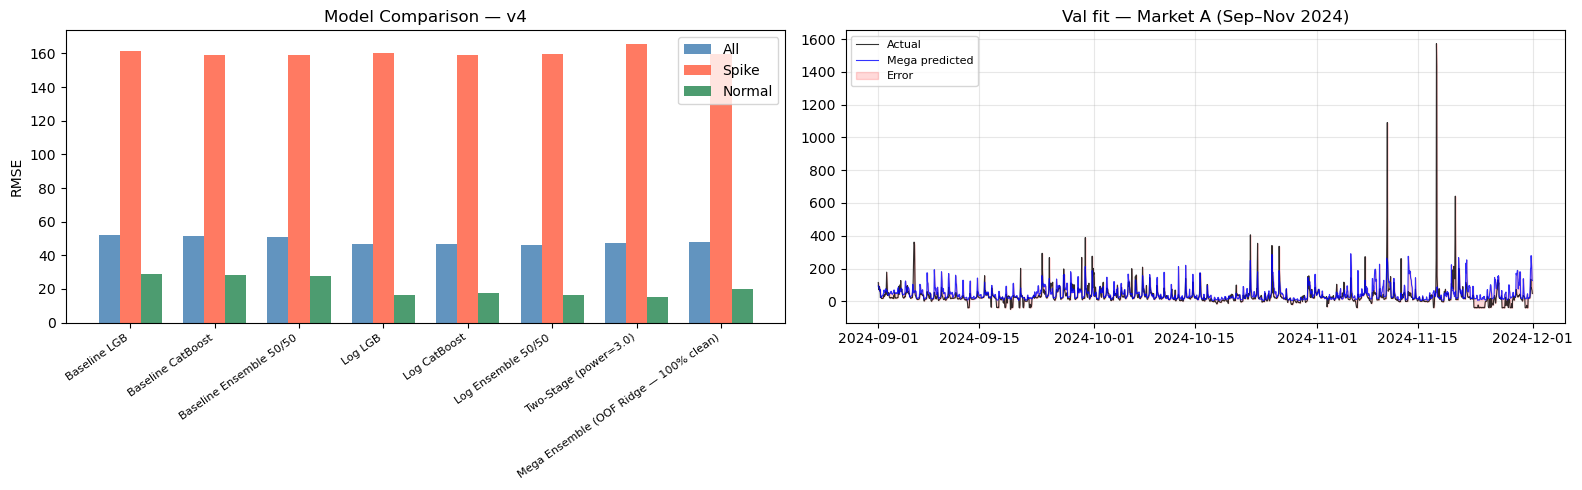

In [11]:
# ── CELL 11: Results summary + plots

print('\n' + '='*75)
print(f'{"Model":<40} {"All":>8} {"Spike":>10} {"Normal":>10}')
print('='*75)
for name, r in sorted(results.items(), key=lambda x: x[1]['all']):
    marker = ' ← best' if name == min(results, key=lambda x: results[x]['all']) else ''
    print(f'{name:<40} {r["all"]:>8.4f} {r["spike"]:>10.4f} {r["normal"]:>10.4f}{marker}')
print('='*75)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names = [n for n in results if 'honest' not in n]  # exclude duplicate ridge entry
x = np.arange(len(names))
w = 0.25
axes[0].bar(x-w, [results[n]['all']    for n in names], w, label='All',    color='steelblue', alpha=0.85)
axes[0].bar(x,   [results[n]['spike']  for n in names], w, label='Spike',  color='tomato',    alpha=0.85)
axes[0].bar(x+w, [results[n]['normal'] for n in names], w, label='Normal', color='seagreen',  alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Model Comparison — v4')
axes[0].legend()

# Val fit plot for mega on first market
mkt = val_chunk[MARKET_COL].cat.categories[0]
msk = (val_chunk[MARKET_COL] == mkt).values
sub_time = val_chunk.loc[msk, TIME_COL].values
sub_act  = y_val[msk]
sub_pred = p_mega[msk]
order    = np.argsort(sub_time)
axes[1].plot(sub_time[order], sub_act[order],  'k-',  lw=0.8, alpha=0.8, label='Actual')
axes[1].plot(sub_time[order], sub_pred[order], 'b-',  lw=0.8, alpha=0.8, label='Mega predicted')
axes[1].fill_between(sub_time[order], sub_act[order], sub_pred[order],
                     alpha=0.15, color='red', label='Error')
axes[1].set_title(f'Val fit — {mkt} (Sep–Nov 2024)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ── CELL 12: Validation predictions CSV export
# Useful for sharing results or further analysis.
# Format: delivery_start, market, target, predicted, residual

val_out = val_chunk[[TIME_COL, MARKET_COL, TARGET_COL]].copy()
val_out['pred_lgb_base']  = p_lgb_base
val_out['pred_lgb_log']   = p_lgb_log
val_out['pred_two_stage'] = p_two_stage
val_out['pred_mega']      = p_mega
val_out['spike_prob']     = spike_prob_val
val_out['is_spike']       = spike_mask_val.astype(int)
val_out['residual_mega']  = val_out[TARGET_COL] - val_out['pred_mega']
val_out['residual_lgb']   = val_out[TARGET_COL] - val_out['pred_lgb_base']

val_out = val_out.sort_values([TIME_COL, MARKET_COL]).reset_index(drop=True)
val_out.to_csv('validation_v4_predictions.csv', index=False)

print('Saved: validation_v4_predictions.csv')
print()
print(val_out.head(6).to_string(index=False))
print()
print('Per-market RMSE (mega):')
for mkt, g in val_out.groupby(MARKET_COL):
    r = np.sqrt(mean_squared_error(g[TARGET_COL], g['pred_mega']))
    bias = g['residual_mega'].mean()
    print(f'  {str(mkt):<12}: RMSE={r:.4f}  bias={bias:+.2f}')

Saved: validation_v4_predictions.csv

delivery_start   market  target  pred_lgb_base  pred_lgb_log  pred_two_stage  pred_mega  spike_prob  is_spike  residual_mega  residual_lgb
    2024-09-01 Market A 114.664      83.063691     66.264272       84.467670  93.382460    0.910196         1      21.281540     31.600309
    2024-09-01 Market B  38.985      43.644214     31.019893       25.496382  33.416095    0.013339         0       5.568905     -4.659214
    2024-09-01 Market C  27.780      43.644214     31.310220       27.350397  32.832569    0.007307         0      -5.052569    -15.864214
    2024-09-01 Market D  29.131      43.851528     30.751913       25.874792  33.115863    0.013008         0      -3.984863    -14.720528
    2024-09-01 Market E  36.451      38.380879     28.222185       25.351794  31.320471    0.004034         0       5.130529     -1.929879
    2024-09-01 Market F  29.609      32.773578     25.657291       24.574464  30.237758    0.000831         0      -0.628758    

In [13]:
# ── CELL 13: Retrain on FULL train
# We use the best_iteration_ found during validation to avoid overfitting.
# No early stopping here — iterations are fixed from the val run.
# OOF spike_prob is recomputed on the full train set.

print('Retraining on FULL train set...')
print(f'Spike threshold for full train: {spike_thresh:.4f} (same as train_bv)')

# ── Step 1: OOF spike_prob for full train
N_FULL      = len(train)
fold_full   = N_FULL // N_FOLDS
oof_full    = np.zeros(N_FULL)
X_full_base = train[ALL_FEATURES]

for fold in range(N_FOLDS):
    v0 = fold * fold_full
    v1 = (fold+1)*fold_full if fold < N_FOLDS-1 else N_FULL
    vi = np.arange(v0, v1)
    ti = np.concatenate([np.arange(0, v0), np.arange(v1, N_FULL)])
    cf = lgb.LGBMClassifier(
        n_estimators=1500, learning_rate=0.03, num_leaves=63,
        class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, force_row_wise=True, n_jobs=-1
    )
    cf.fit(X_full_base.iloc[ti], train['is_spike'].values[ti],
           categorical_feature=[MARKET_COL])
    oof_full[vi] = cf.predict_proba(X_full_base.iloc[vi])[:, 1]
    print(f'  Full classifier fold {fold+1}/{N_FOLDS}')

# Final classifier for test predictions
clf_final = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.03, num_leaves=63,
    class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, force_row_wise=True, n_jobs=-1
)
clf_final.fit(X_full_base, train['is_spike'].values,
              categorical_feature=[MARKET_COL])

train['spike_prob'] = oof_full
test['spike_prob']  = clf_final.predict_proba(test[ALL_FEATURES])[:, 1]

X_full = train[ALL_FEATURES_V2].reset_index(drop=True)
y_full = train[TARGET_COL].values
w_full = train['sample_weight'].values
spike_mask_full = train['is_spike'].values.astype(bool)

# ── Step 2: LGB base full
lgb_full_base = lgb.LGBMRegressor(**{**LGB_BASE, 'n_estimators': lgb_base.best_iteration_})
lgb_full_base.fit(X_full, y_full, sample_weight=w_full,
                  categorical_feature=[MARKET_COL])
print('LGB base full: done')

# ── Step 3: CB base full
Xf = X_full.copy(); Xf[MARKET_COL] = Xf[MARKET_COL].astype(str)
cb_full_base = cb.CatBoostRegressor(**{**CB_BASE, 'iterations': cb_base.best_iteration_})
cb_full_base.fit(Xf, y_full, sample_weight=w_full, cat_features=[MARKET_COL])
print('CB base full: done')

# ── Step 4: LGB log full
lgb_full_log = lgb.LGBMRegressor(**{**LGB_BASE, 'n_estimators': lgb_log.best_iteration_})
lgb_full_log.fit(X_full, log_transform(y_full), sample_weight=w_full,
                 categorical_feature=[MARKET_COL])
print('LGB log full: done')

# ── Step 5: CB log full
Xfl = X_full.copy(); Xfl[MARKET_COL] = Xfl[MARKET_COL].astype(str)
cb_full_log = cb.CatBoostRegressor(**{**CB_BASE, 'iterations': cb_log.best_iteration_})
cb_full_log.fit(Xfl, log_transform(y_full), sample_weight=w_full,
                cat_features=[MARKET_COL])
print('CB log full: done')

# ── Step 6: Two-stage full
lgb_full_normal = lgb.LGBMRegressor(
    **{**LGB_BASE, 'n_estimators': lgb_normal.best_iteration_})
lgb_full_normal.fit(
    X_full[~spike_mask_full], y_full[~spike_mask_full],
    categorical_feature=[MARKET_COL])

lgb_full_spike_raw = lgb.LGBMRegressor(
    **{**LGB_BASE, 'n_estimators': lgb_spike_raw.best_iteration_,
       'num_leaves': 63, 'objective': 'huber', 'alpha': 0.9})
lgb_full_spike_raw.fit(
    X_full[spike_mask_full], y_full[spike_mask_full],
    categorical_feature=[MARKET_COL])

lgb_full_spike_log = lgb.LGBMRegressor(
    **{**LGB_BASE, 'n_estimators': lgb_spike_log.best_iteration_,
       'num_leaves': 63})
lgb_full_spike_log.fit(
    X_full[spike_mask_full], log_transform(y_full[spike_mask_full]),
    categorical_feature=[MARKET_COL])

print('Two-stage full: done')
print('\nAll full models trained successfully.')

Retraining on FULL train set...
Spike threshold for full train: 53.7841 (same as train_bv)
[LightGBM] [Info] Number of positive: 11067, number of negative: 95020
[LightGBM] [Info] Total Bins 29017
[LightGBM] [Info] Number of data points in the train set: 106087, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
  Full classifier fold 1/5
[LightGBM] [Info] Number of positive: 10149, number of negative: 95938
[LightGBM] [Info] Total Bins 28997
[LightGBM] [Info] Number of data points in the train set: 106087, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
  Full classifier fold 2/5
[LightGBM] [Info] Number of positive: 10980, number of negative: 95107
[LightGBM] [Info] Total Bins 29013
[LightGBM] [Info] Number of data points in the train set: 106087, number of used fe

Test prediction stats:
Model              mean      std        max      p99
------------------------------------------
lgb_base          41.56    34.73     821.92   162.88
cb_base           38.44    36.07     702.30   174.48
lgb_log           25.25    22.55     144.20   105.58
two_stage         24.90    21.23     175.84   109.84
mega              32.74    27.30     454.38   137.43


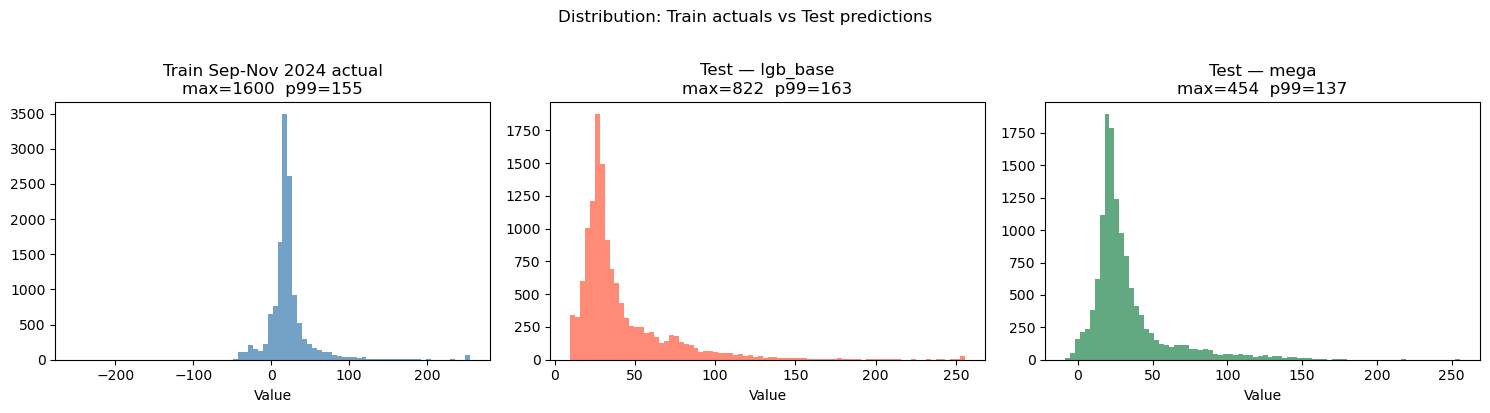

In [14]:
# ── CELL 14: Test predictions
X_test = test[ALL_FEATURES_V2]

# Base
pt_lgb_base = lgb_full_base.predict(X_test)
Xt = X_test.copy(); Xt[MARKET_COL] = Xt[MARKET_COL].astype(str)
pt_cb_base  = cb_full_base.predict(Xt)

# Log
pt_lgb_log  = inv_log_transform(lgb_full_log.predict(X_test))
Xtl = X_test.copy(); Xtl[MARKET_COL] = Xtl[MARKET_COL].astype(str)
pt_cb_log   = inv_log_transform(cb_full_log.predict(Xtl))

# Two-stage
pt_normal   = lgb_full_normal.predict(X_test)
pt_spike    = (0.5 * lgb_full_spike_raw.predict(X_test) +
               0.5 * inv_log_transform(lgb_full_spike_log.predict(X_test)))
test_bp     = test['spike_prob'].values ** best_power
pt_two      = (1 - test_bp)*pt_normal + test_bp*pt_spike

# Mega
test_stack  = np.column_stack([pt_lgb_base, pt_cb_base,
                                pt_lgb_log,  pt_cb_log, pt_two])
pt_mega     = test_stack @ weights_norm

print('Test prediction stats:')
print(f'{"Model":<14} {"mean":>8} {"std":>8} {"max":>10} {"p99":>8}')
print('-'*42)
for name, p in [('lgb_base',  pt_lgb_base),
                ('cb_base',   pt_cb_base),
                ('lgb_log',   pt_lgb_log),
                ('two_stage', pt_two),
                ('mega',      pt_mega)]:
    print(f'{name:<14} {p.mean():>8.2f} {p.std():>8.2f} '
          f'{p.max():>10.2f} {np.percentile(p,99):>8.2f}')

# Distribution plot: compare test predictions vs train Sep-Nov 2024
same_period = train[
    (train[TIME_COL] >= '2024-09-01') &
    (train[TIME_COL] <  '2024-12-01')
][TARGET_COL]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clip = same_period.quantile(0.995)
for ax, (name, p, color) in zip(axes, [
    ('Train Sep-Nov 2024 actual', same_period.values, 'steelblue'),
    ('Test — lgb_base',           pt_lgb_base,        'tomato'),
    ('Test — mega',               pt_mega,             'seagreen'),
]):
    ax.hist(np.clip(p, None, clip), bins=80, color=color, alpha=0.75)
    ax.set_title(f'{name}\nmax={p.max():.0f}  p99={np.percentile(p,99):.0f}')
    ax.set_xlabel('Value')
plt.suptitle('Distribution: Train actuals vs Test predictions', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# ── CELL 15: Save submissions
# Change SUBMIT_MODELS to include whichever models you want to submit.

SUBMIT_MODELS = {
    'mega'     : pt_mega,
    'lgb_base' : pt_lgb_base,
    'lgb_log'  : pt_lgb_log,
}

for name, preds in SUBMIT_MODELS.items():
    s = test[[ID_COL]].copy()
    s['target'] = preds
    fname = f'submission_v4_{name}.csv'
    s.to_csv(fname, index=False)
    print(f'Saved: {fname}  ({len(s)} rows)')

print()
print('=' * 75)
print('FINAL VALIDATION SUMMARY (v4 — all fixes applied)')
print('=' * 75)
print(f'{"Model":<40} {"All":>8} {"Spike":>10} {"Normal":>10}')
print('-' * 75)
for name, r in sorted(results.items(), key=lambda x: x[1]['all']):
    best_marker = ' ✓' if name == min(results, key=lambda x: results[x]['all']) else ''
    print(f'{name:<40} {r["all"]:>8.4f} {r["spike"]:>10.4f} {r["normal"]:>10.4f}{best_marker}')
print('=' * 75)
print()
print('Spike threshold used everywhere: ', round(spike_thresh, 4), ' (from train_bv only — Fix A+C)')
print('Ridge: OOF weights from train_bv — val 100% clean (Fix B)')
print()
print('Recommended submissions:')
print('  1. submission_v4_mega.csv     — best overall RMSE')
print('  2. submission_v4_lgb_base.csv — highest spike predictions (max test)')

Saved: submission_v4_mega.csv  (13098 rows)
Saved: submission_v4_lgb_base.csv  (13098 rows)
Saved: submission_v4_lgb_log.csv  (13098 rows)

FINAL VALIDATION SUMMARY (v4 — all fixes applied)
Model                                         All      Spike     Normal
---------------------------------------------------------------------------
Log Ensemble 50/50                        46.3899   159.4793    16.6241 ✓
Log LGB                                   46.4516   160.1688    16.2725
Log CatBoost                              46.5634   159.2394    17.3190
Two-Stage (power=3.0)                     47.5316   165.4967    15.3195
Mega Ensemble (OOF Ridge — 100% clean)    47.7019   159.7239    20.0866
Baseline Ensemble 50/50                   51.0008   159.0577    27.7923
Baseline CatBoost                         51.2112   159.2838    28.1043
Baseline LGB                              52.1092   161.1936    28.9967

Spike threshold used everywhere:  53.7841  (from train_bv only — Fix A+C)
Ridge: OO